# Lab 2: Cats vs Dogs

In this lab, you will train a convolutional neural network to classify an image 
into one of two classes: "cat" or "dog". The code for the neural networks 
you train will be written for you, and you are not (yet!) expected
to understand all provided code. However, by the end of the lab,
you should be able to:

1. Understand at a high level the training loop for a machine learning model.
2. Understand the distinction between training, validation, and test data.
3. The concepts of overfitting and underfitting.
4. Investigate how different hyperparameters, such as learning rate and batch size, affect the success of training.
5. Compare an ANN (aka Multi-Layer Perceptron) with a CNN.

### What to submit

Submit a PDF file containing all your code, outputs, and write-up
from parts 1-5. You can produce a PDF of your Google Colab file by
going to **File > Print** and then save as PDF. The Colab instructions
has more information.

**Do not submit any other files produced by your code.**

Include a link to your colab file in your submission.

Please use Google Colab to complete this assignment. If you want to use Jupyter Notebook, please complete the assignment and upload your Jupyter Notebook file to Google Colab for submission. 

With Colab, you can export a PDF file using the menu option
`File -> Print` and save as PDF file. **Adjust the scaling to ensure that the text is not cutoff at the margins.**

## Colab Link

Include a link to your colab file here

Colab Link: 

In [1]:
import numpy as np
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torch.utils.data.sampler import SubsetRandomSampler
import torchvision.transforms as transforms


## Part 0. Helper Functions

We will be making use of the following helper functions. You will be asked to look
at and possibly modify some of these, but you are not expected to understand all of them.

You should look at the function names and read the docstrings. If you are curious, come back and explore the code *after* making some progress on the lab.

In [7]:
###############################################################################
# Data Loading

def get_relevant_indices(dataset, classes, target_classes):
    """ Return the indices for datapoints in the dataset that belongs to the
    desired target classes, a subset of all possible classes.

    Args:
        dataset: Dataset object
        classes: A list of strings denoting the name of each class
        target_classes: A list of strings denoting the name of desired classes
                        Should be a subset of the 'classes'
    Returns:
        indices: list of indices that have labels corresponding to one of the
                 target classes
    """
    indices = []
    for i in range(len(dataset)):
        # Check if the label is in the target classes
        label_index = dataset[i][1] # ex: 3
        label_class = classes[label_index] # ex: 'cat'
        if label_class in target_classes:
            indices.append(i)
    return indices

def get_data_loader(target_classes, batch_size):
    """ Loads images of cats and dogs, splits the data into training, validation
    and testing datasets. Returns data loaders for the three preprocessed datasets.

    Args:
        target_classes: A list of strings denoting the name of the desired
                        classes. Should be a subset of the argument 'classes'
        batch_size: A int representing the number of samples per batch
    
    Returns:
        train_loader: iterable training dataset organized according to batch size
        val_loader: iterable validation dataset organized according to batch size
        test_loader: iterable testing dataset organized according to batch size
        classes: A list of strings denoting the name of each class
    """

    classes = ('plane', 'car', 'bird', 'cat',
               'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
    ########################################################################
    # The output of torchvision datasets are PILImage images of range [0, 1].
    # We transform them to Tensors of normalized range [-1, 1].
    transform = transforms.Compose(
        [transforms.ToTensor(),
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
    # Load CIFAR10 training data
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                            download=True, transform=transform)
    # Get the list of indices to sample from
    relevant_indices = get_relevant_indices(trainset, classes, target_classes)
    
    # Split into train and validation
    np.random.seed(1000) # Fixed numpy random seed for reproducible shuffling
    np.random.shuffle(relevant_indices)
    split = int(len(relevant_indices) * 0.8) #split at 80%
    
    # split into training and validation indices
    relevant_train_indices, relevant_val_indices = relevant_indices[:split], relevant_indices[split:]  
    train_sampler = SubsetRandomSampler(relevant_train_indices)
    train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                               num_workers=1, sampler=train_sampler)
    val_sampler = SubsetRandomSampler(relevant_val_indices)
    val_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                              num_workers=1, sampler=val_sampler)
    # Load CIFAR10 testing data
    testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                           download=True, transform=transform)
    # Get the list of indices to sample from
    relevant_test_indices = get_relevant_indices(testset, classes, target_classes)
    test_sampler = SubsetRandomSampler(relevant_test_indices)
    test_loader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                             num_workers=1, sampler=test_sampler)
    return train_loader, val_loader, test_loader, classes

###############################################################################
# Training
def get_model_name(name, batch_size, learning_rate, epoch):
    """ Generate a name for the model consisting of all the hyperparameter values

    Args:
        config: Configuration object containing the hyperparameters
    Returns:
        path: A string with the hyperparameter name and value concatenated
    """
    path = "model_{0}_bs{1}_lr{2}_epoch{3}".format(name,
                                                   batch_size,
                                                   learning_rate,
                                                   epoch)
    return path

def normalize_label(labels):
    """
    Given a tensor containing 2 possible values, normalize this to 0/1

    Args:
        labels: a 1D tensor containing two possible scalar values
    Returns:
        A tensor normalize to 0/1 value
    """
    max_val = torch.max(labels)
    min_val = torch.min(labels)
    norm_labels = (labels - min_val)/(max_val - min_val)
    return norm_labels

def evaluate(net, loader, criterion):
    """ Evaluate the network on the validation set.

     Args:
         net: PyTorch neural network object
         loader: PyTorch data loader for the validation set
         criterion: The loss function
     Returns:
         err: A scalar for the avg classification error over the validation set
         loss: A scalar for the average loss function over the validation set
     """
    total_loss = 0.0
    total_err = 0.0
    total_epoch = 0
    for i, data in enumerate(loader, 0):
        inputs, labels = data
        labels = normalize_label(labels)  # Convert labels to 0/1
        outputs = net(inputs)
        loss = criterion(outputs, labels.float())
        corr = (outputs > 0.0).squeeze().long() != labels
        total_err += int(corr.sum())
        total_loss += loss.item()
        total_epoch += len(labels)
    err = float(total_err) / total_epoch
    loss = float(total_loss) / (i + 1)
    return err, loss

###############################################################################
# Training Curve
def plot_training_curve(path):
    """ Plots the training curve for a model run, given the csv files
    containing the train/validation error/loss.

    Args:
        path: The base path of the csv files produced during training
    """
    import matplotlib.pyplot as plt
    train_err = np.loadtxt("{}_train_err.csv".format(path))
    val_err = np.loadtxt("{}_val_err.csv".format(path))
    train_loss = np.loadtxt("{}_train_loss.csv".format(path))
    val_loss = np.loadtxt("{}_val_loss.csv".format(path))
    plt.title("Train vs Validation Error")
    n = len(train_err) # number of epochs
    plt.plot(range(1,n+1), train_err, label="Train")
    plt.plot(range(1,n+1), val_err, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Error")
    plt.legend(loc='best')
    plt.show()
    plt.title("Train vs Validation Loss")
    plt.plot(range(1,n+1), train_loss, label="Train")
    plt.plot(range(1,n+1), val_loss, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(loc='best')
    plt.show()

## Part 1. Visualizing the Data [7 pt]

We will make use of some of the CIFAR-10 data set, which consists of 
colour images of size 32x32 pixels belonging to 10 categories. You can
find out more about the dataset at https://www.cs.toronto.edu/~kriz/cifar.html

For this assignment, we will only be using the cat and dog categories. 
We have included code that automatically downloads the dataset the 
first time that the main script is run.

In [4]:
# This will download the CIFAR-10 dataset to a folder called "data"
# the first time you run this code.
train_loader, val_loader, test_loader, classes = get_data_loader(
    target_classes=["cat", "dog"], 
    batch_size=1) # One image per batch

99.1%

### Part (a) -- 1 pt

Visualize some of the data by running the code below.
Include the visualization in your writeup.

(You don't need to submit anything else.)

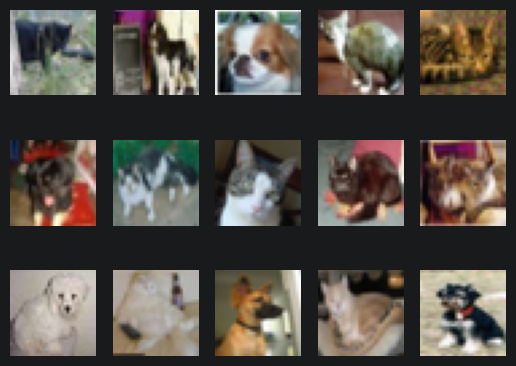

In [10]:
import matplotlib.pyplot as plt

k = 0
for images, labels in val_loader:
    # since batch_size = 1, there is only 1 image in `images`
    image = images[0]
    # place the colour channel at the end, instead of at the beginning
    img = np.transpose(image, [1,2,0])
    # normalize pixel intensity values to [0, 1]
    img = img / 2 + 0.5
    plt.subplot(3, 5, k+1)
    plt.axis('off')
    plt.imshow(img)

    k += 1
    if k > 14:
        break

### Part (b) -- 3 pt

How many training examples do we have for the combined `cat` and `dog` classes? 
What about validation examples? 
What about test examples?

In [ ]:
"""15 training examples,15 test examples,15 validation exaples"""

### Part (c) -- 3pt

Why do we need a validation set when training our model? What happens if we judge the 
performance of our models using the training set loss/error instead of the validation
set loss/error?

In [ ]:
"""because we need validation set to improve the confidence level of our traning, then the model will be like training model and leads to overfitting."""

## Part 2. Training [15 pt]

We define two neural networks, a `LargeNet` and `SmallNet`.
We'll be training the networks in this section.

You won't understand fully what these networks are doing until
the next few classes, and that's okay. For this assignment, please
focus on learning how to train networks, and how hyperparameters affect
training.

In [8]:
class LargeNet(nn.Module):
    def __init__(self):
        super(LargeNet, self).__init__()
        self.name = "large"
        self.conv1 = nn.Conv2d(3, 5, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(5, 10, 5)
        self.fc1 = nn.Linear(10 * 5 * 5, 32)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 10 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        x = x.squeeze(1) # Flatten to [batch_size]
        return x

In [9]:
class SmallNet(nn.Module):
    def __init__(self):
        super(SmallNet, self).__init__()
        self.name = "small"
        self.conv = nn.Conv2d(3, 5, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(5 * 7 * 7, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv(x)))
        x = self.pool(x)
        x = x.view(-1, 5 * 7 * 7)
        x = self.fc(x)
        x = x.squeeze(1) # Flatten to [batch_size]
        return x

In [10]:
small_net = SmallNet()
large_net = LargeNet()

### Part (a) -- 2pt

The methods `small_net.parameters()` and `large_net.parameters()`
produces an iterator of all the trainable parameters of the network.
These parameters are torch tensors containing many scalar values. 

We haven't learned how how the parameters in these high-dimensional
tensors will be used, but we should be able to count the number
of parameters. Measuring the number of parameters in a network is
one way of measuring the "size" of a network.

What is the total number of parameters in `small_net` and in
`large_net`? (Hint: how many numbers are in each tensor?)

In [14]:
for param in small_net.parameters():
    print(param.shape)

torch.Size([5, 3, 3, 3])
torch.Size([5])
torch.Size([1, 245])
torch.Size([1])


### The function train_net

The function `train_net` below takes an untrained neural network (like `small_net` and `large_net`) and
several other parameters. You should be able to understand how this function works.
The figure below shows the high level training loop for a machine learning model:

![alt text](https://github.com/UTNeural/Lab2/blob/master/Diagram.png?raw=true)

In [15]:
def train_net(net, batch_size=64, learning_rate=0.01, num_epochs=30):
    ########################################################################
    # Train a classifier on cats vs dogs
    target_classes = ["cat", "dog"]
    ########################################################################
    # Fixed PyTorch random seed for reproducible result
    torch.manual_seed(1000)
    ########################################################################
    # Obtain the PyTorch data loader objects to load batches of the datasets
    train_loader, val_loader, test_loader, classes = get_data_loader(
            target_classes, batch_size)
    ########################################################################
    # Define the Loss function and optimizer
    # The loss function will be Binary Cross Entropy (BCE). In this case we
    # will use the BCEWithLogitsLoss which takes unnormalized output from
    # the neural network and scalar label.
    # Optimizer will be SGD with Momentum.
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.SGD(net.parameters(), lr=learning_rate, momentum=0.9)
    ########################################################################
    # Set up some numpy arrays to store the training/test loss/erruracy
    train_err = np.zeros(num_epochs)
    train_loss = np.zeros(num_epochs)
    val_err = np.zeros(num_epochs)
    val_loss = np.zeros(num_epochs)
    ########################################################################
    # Train the network
    # Loop over the data iterator and sample a new batch of training data
    # Get the output from the network, and optimize our loss function.
    start_time = time.time()
    for epoch in range(num_epochs):  # loop over the dataset multiple times
        total_train_loss = 0.0
        total_train_err = 0.0
        total_epoch = 0
        for i, data in enumerate(train_loader, 0):
            # Get the inputs
            inputs, labels = data
            labels = normalize_label(labels) # Convert labels to 0/1
            # Zero the parameter gradients
            optimizer.zero_grad()
            # Forward pass, backward pass, and optimize
            outputs = net(inputs)
            loss = criterion(outputs, labels.float())
            loss.backward()
            optimizer.step()
            # Calculate the statistics
            corr = (outputs > 0.0).squeeze().long() != labels
            total_train_err += int(corr.sum())
            total_train_loss += loss.item()
            total_epoch += len(labels)
        train_err[epoch] = float(total_train_err) / total_epoch
        train_loss[epoch] = float(total_train_loss) / (i+1)
        val_err[epoch], val_loss[epoch] = evaluate(net, val_loader, criterion)
        print(("Epoch {}: Train err: {}, Train loss: {} |"+
               "Validation err: {}, Validation loss: {}").format(
                   epoch + 1,
                   train_err[epoch],
                   train_loss[epoch],
                   val_err[epoch],
                   val_loss[epoch]))
        # Save the current model (checkpoint) to a file
        model_path = get_model_name(net.name, batch_size, learning_rate, epoch)
        torch.save(net.state_dict(), model_path)
    print('Finished Training')
    end_time = time.time()
    elapsed_time = end_time - start_time
    print("Total time elapsed: {:.2f} seconds".format(elapsed_time))
    # Write the train/test loss/err into CSV file for plotting later
    epochs = np.arange(1, num_epochs + 1)
    np.savetxt("{}_train_err.csv".format(model_path), train_err)
    np.savetxt("{}_train_loss.csv".format(model_path), train_loss)
    np.savetxt("{}_val_err.csv".format(model_path), val_err)
    np.savetxt("{}_val_loss.csv".format(model_path), val_loss)

### Part (b) -- 1pt

The parameters to the function `train_net` are hyperparameters of our neural network.
We made these hyperparameters easy to modify so that we can tune them later on. 

What are the default values of the parameters `batch_size`, `learning_rate`, 
and `num_epochs`?

In [ ]:
"""batch_size=64, learning_rate=0.01, num_epochs=30
   """

### Part (c) -- 3 pt

What files are written to disk when we call `train_net` with `small_net`, and train for 5 epochs? Provide a list
of all the files written to disk, and what information the files contain.

In [ ]:
"""model_small_net_bs64_lr0.01_epoch0
model_small_net_bs64_lr0.01_epoch1
model_small_net_bs64_lr0.01_epoch2
model_small_net_bs64_lr0.01_epoch3
model_small_net_bs64_lr0.01_epoch4
5 file contains the weights of the network for the 5 epochs

train_err.csv the file contains the training set errors rate
train_loss.csv the file contains total training set losses
val_err.csv the file contains the validation set errors rate
val_loss.csv   the file contains total validation set losses"""

### Part (d) -- 2pt

Train both `small_net` and `large_net` using the function `train_net` and its default parameters.
The function will write many files to disk, including a model checkpoint (saved values of model weights) 
at the end of each epoch.

If you are using Google Colab, you will need to mount Google Drive 
so that the files generated by `train_net` gets saved. We will be using
these files in part (d).
(See the Google Colab tutorial for more information about this.)

Report the total time elapsed when training each network. Which network took longer to train?
Why?

In [ ]:
# Since the function writes files to disk, you will need to mount
# your Google Drive. If you are working on the lab locally, you
# can comment out this code.


from google.colab import drive
drive.mount('/content/gdrive')

In [14]:
train_net(small_net, batch_size=64, learning_rate=0.01, num_epochs=30)
train_net(large_net, batch_size=64, learning_rate=0.01, num_epochs=30)


""" small net took 418.01 seconds, big net took 436.33 seconds, the big net took longer mainly becasue it has more layer to compute, which made each epochs slower"""

Epoch 1: Train err: 0.422375, Train loss: 0.6730743145942688 |Validation err: 0.3805, Validation loss: 0.6553599610924721
Epoch 2: Train err: 0.372875, Train loss: 0.6465341424942017 |Validation err: 0.3785, Validation loss: 0.6545888334512711
Epoch 3: Train err: 0.361625, Train loss: 0.6385869011878967 |Validation err: 0.339, Validation loss: 0.6275563519448042
Epoch 4: Train err: 0.344875, Train loss: 0.6256614227294922 |Validation err: 0.3425, Validation loss: 0.62219481728971
Epoch 5: Train err: 0.33875, Train loss: 0.6152738466262817 |Validation err: 0.3245, Validation loss: 0.6149830874055624
Epoch 6: Train err: 0.324875, Train loss: 0.604004210472107 |Validation err: 0.3315, Validation loss: 0.6141039375215769
Epoch 7: Train err: 0.3185, Train loss: 0.5976182870864868 |Validation err: 0.33, Validation loss: 0.6087306700646877
Epoch 8: Train err: 0.31275, Train loss: 0.5880128247737885 |Validation err: 0.318, Validation loss: 0.6017135065048933
Epoch 9: Train err: 0.313, Train lo

### Part (e) - 2pt

Use the function `plot_training_curve` to display the trajectory of the 
training/validation error and the training/validation loss.
You will need to use the function `get_model_name` to generate the
argument to the `plot_training_curve` function.

Do this for both the small network and the large network. Include both plots
in your writeup.

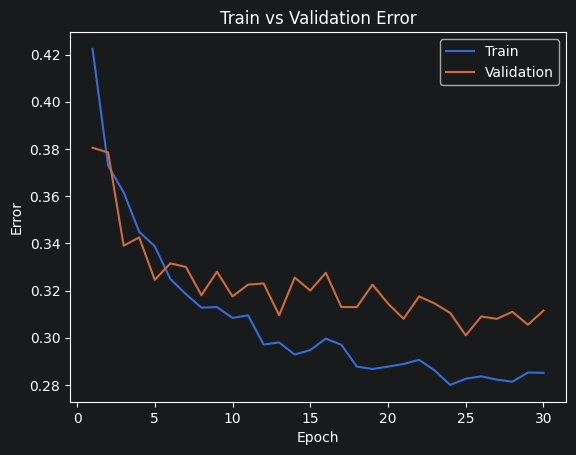

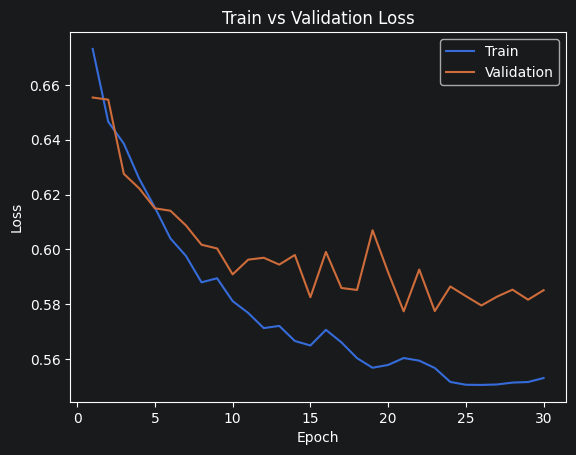

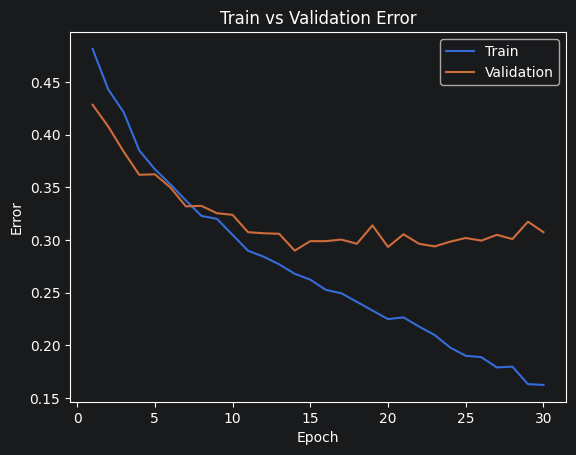

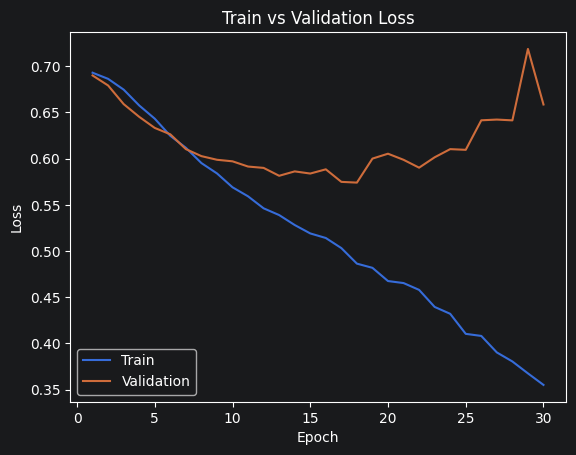

In [16]:
#model_path = get_model_name("small", batch_size=??, learning_rate=??, epoch=29)
model_path = get_model_name(small_net.name, batch_size=64, learning_rate=0.01, epoch=29)
plot_training_curve(model_path)
model_path = get_model_name(large_net.name, batch_size=64, learning_rate=0.01, epoch=29)
plot_training_curve(model_path)

### Part (f) - 5pt

Describe what you notice about the training curve.
How do the curves differ for `small_net` and `large_net`?
Identify any occurences of underfitting and overfitting.

In [5]:
"""the big net's loss and error has a big overfitting happening, and small net 's model of training data fail to to learn because it cant learn enough for the model(its too simple), and yet both have a smilirar error rate, but two different reasons"""

"the big net's loss and error has a big overfitting happening, and small net 's model of training data fail to to learn because it cant learn enough for the model(its too simple), and yet both have a smilirar error rate, but two different reasons"

## Part 3. Optimization Parameters [12 pt]

For this section, we will work with `large_net` only.

### Part (a) - 3pt

Train `large_net` with all default parameters, except set `learning_rate=0.001`.
Does the model take longer/shorter to train?
Plot the training curve. Describe the effect of *lowering* the learning rate.

Epoch 1: Train err: 0.50225, Train loss: 0.6945205326080323 |Validation err: 0.491, Validation loss: 0.6929903794080019
Epoch 2: Train err: 0.50225, Train loss: 0.693027461528778 |Validation err: 0.491, Validation loss: 0.692411633208394
Epoch 3: Train err: 0.487375, Train loss: 0.6922529015541077 |Validation err: 0.4765, Validation loss: 0.6920251790434122
Epoch 4: Train err: 0.448375, Train loss: 0.6916863393783569 |Validation err: 0.4515, Validation loss: 0.6913809273391962
Epoch 5: Train err: 0.441875, Train loss: 0.6910700497627258 |Validation err: 0.441, Validation loss: 0.6910937018692493
Epoch 6: Train err: 0.44025, Train loss: 0.6903751420974732 |Validation err: 0.4375, Validation loss: 0.6905087828636169
Epoch 7: Train err: 0.438125, Train loss: 0.6895530438423156 |Validation err: 0.4345, Validation loss: 0.6896944772452116
Epoch 8: Train err: 0.43875, Train loss: 0.6884724521636962 |Validation err: 0.4335, Validation loss: 0.6885982919484377
Epoch 9: Train err: 0.44225, Trai

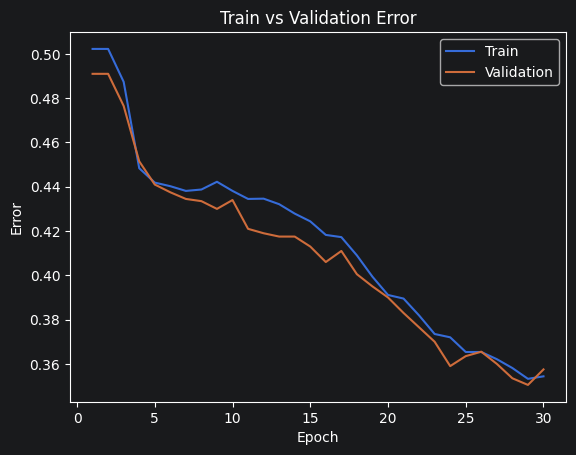

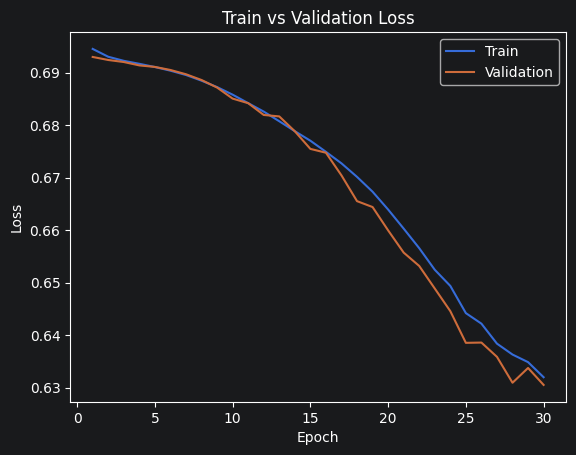

In [18]:
# Note: When we re-construct the model, we start the training
# with *random weights*. If we omit this code, the values of
# the weights will still be the previously trained values.
large_net = LargeNet()
train_net(large_net, batch_size=64, learning_rate=0.001, num_epochs=30)
model_path = get_model_name(large_net.name, batch_size=64, learning_rate=0.001, epoch=29)
plot_training_curve(model_path)
""" lower the lr ,makes the model take smaller weight update steps,so it will be slow and stable convergence,as we can see, the curve got smoother and the gap is very small between training and validation, this means that our model is not overfitting anymore, but it leads to underfitting ."""

### Part (b) - 3pt

Train `large_net` with all default parameters, except set `learning_rate=0.1`. 
Does the model take longer/shorter to train?
Plot the training curve. Describe the effect of *increasing* the learning rate.


Epoch 1: Train err: 0.44775, Train loss: 0.6812482957839966 |Validation err: 0.383, Validation loss: 0.6483798865228891
Epoch 2: Train err: 0.3755, Train loss: 0.6498857498168945 |Validation err: 0.3665, Validation loss: 0.6401216089725494
Epoch 3: Train err: 0.347, Train loss: 0.6210229582786561 |Validation err: 0.3315, Validation loss: 0.6065378095954657
Epoch 4: Train err: 0.336875, Train loss: 0.6108469772338867 |Validation err: 0.357, Validation loss: 0.6699712872505188
Epoch 5: Train err: 0.3155, Train loss: 0.59064728474617 |Validation err: 0.3015, Validation loss: 0.5795890130102634
Epoch 6: Train err: 0.29925, Train loss: 0.5676507868766785 |Validation err: 0.312, Validation loss: 0.616675591096282
Epoch 7: Train err: 0.285625, Train loss: 0.55593461227417 |Validation err: 0.308, Validation loss: 0.5773766133934259
Epoch 8: Train err: 0.277, Train loss: 0.5413990960121154 |Validation err: 0.2915, Validation loss: 0.5700584417209029
Epoch 9: Train err: 0.267375, Train loss: 0.5

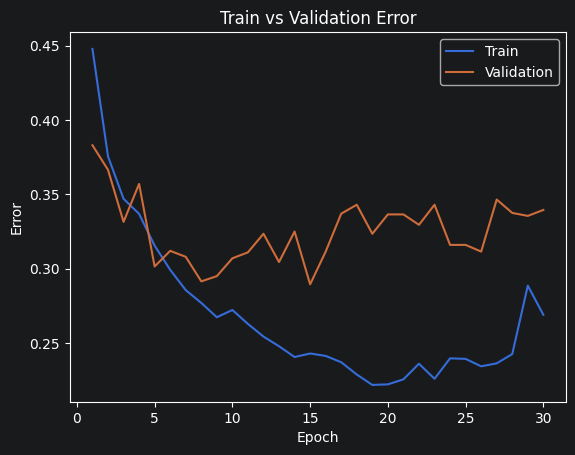

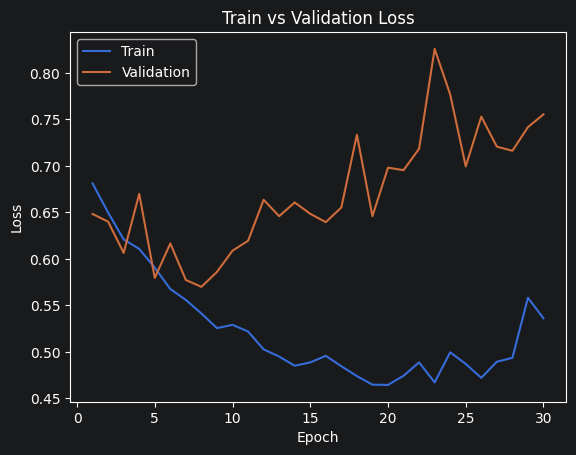

In [17]:
large_net = LargeNet()
train_net(large_net, batch_size=64, learning_rate=0.1, num_epochs=30)
model_path = get_model_name(large_net.name, batch_size=64, learning_rate=0.1, epoch=29)
plot_training_curve(model_path)
"""Raising the learning rate makes the model take larger weight update steps, the result is obvious, there is a huge gap between training and our validation set result,our model cant well studied the training set , leading to a over 0.3 error as result, and failed on the validation to with a even higher error rate, leading to huge overfitting"""

### Part (c) - 3pt

Train `large_net` with all default parameters, including with `learning_rate=0.01`.
Now, set `batch_size=512`. Does the model take longer/shorter to train?
Plot the training curve. Describe the effect of *increasing* the batch size.

Epoch 1: Train err: 0.48175, Train loss: 0.6929379515349865 |Validation err: 0.478, Validation loss: 0.6926823556423187
Epoch 2: Train err: 0.457625, Train loss: 0.6924104019999504 |Validation err: 0.434, Validation loss: 0.6917425245046616
Epoch 3: Train err: 0.437, Train loss: 0.691650029271841 |Validation err: 0.4265, Validation loss: 0.6909129023551941
Epoch 4: Train err: 0.433625, Train loss: 0.6908449344336987 |Validation err: 0.424, Validation loss: 0.6897872388362885
Epoch 5: Train err: 0.433875, Train loss: 0.6896937787532806 |Validation err: 0.424, Validation loss: 0.6881359368562698
Epoch 6: Train err: 0.438375, Train loss: 0.6883536092936993 |Validation err: 0.4285, Validation loss: 0.6860135495662689
Epoch 7: Train err: 0.439375, Train loss: 0.6866877600550652 |Validation err: 0.426, Validation loss: 0.6836969703435898
Epoch 8: Train err: 0.435375, Train loss: 0.6849774345755577 |Validation err: 0.4115, Validation loss: 0.6814667731523514
Epoch 9: Train err: 0.42375, Train

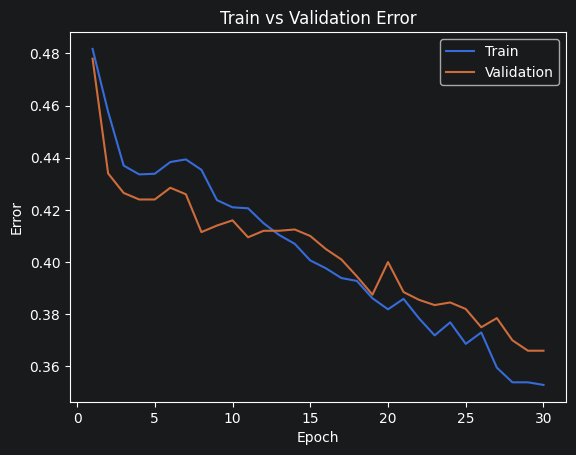

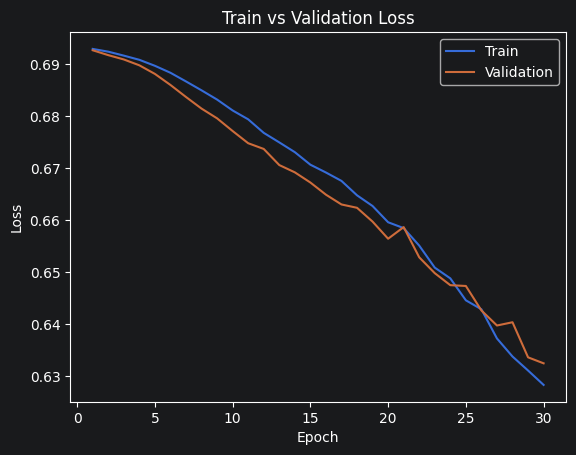

In [18]:
large_net = LargeNet()
train_net(large_net, batch_size=512, learning_rate=0.01, num_epochs=30)
model_path = get_model_name(large_net.name, batch_size=512, learning_rate=0.01, epoch=29)
plot_training_curve(model_path)
"""increasing batch size to 512 decrease the number of weight updates , the error is still 0.35 which leads to underfitting, the small gap shows that the model cant learn enough for the set"""

### Part (d) - 3pt

Train `large_net` with all default parameters, including with `learning_rate=0.01`.
Now, set `batch_size=16`. Does the model take longer/shorter to train?
Plot the training curve. Describe the effect of *decreasing* the batch size.

Epoch 1: Train err: 0.43225, Train loss: 0.6775093417167664 |Validation err: 0.3765, Validation loss: 0.6523821382522583
Epoch 2: Train err: 0.369625, Train loss: 0.640163824737072 |Validation err: 0.3485, Validation loss: 0.620235032081604
Epoch 3: Train err: 0.34075, Train loss: 0.6132751225233078 |Validation err: 0.3515, Validation loss: 0.6601082136631012
Epoch 4: Train err: 0.31025, Train loss: 0.5849400263428688 |Validation err: 0.358, Validation loss: 0.6216982991695404
Epoch 5: Train err: 0.30725, Train loss: 0.5690071796178817 |Validation err: 0.298, Validation loss: 0.5765989832878112
Epoch 6: Train err: 0.2835, Train loss: 0.5463019408583641 |Validation err: 0.3115, Validation loss: 0.5873636491298676
Epoch 7: Train err: 0.27425, Train loss: 0.5319214688241481 |Validation err: 0.306, Validation loss: 0.5768398849964141
Epoch 8: Train err: 0.26225, Train loss: 0.5196046289205551 |Validation err: 0.313, Validation loss: 0.5815399966239929
Epoch 9: Train err: 0.2535, Train loss

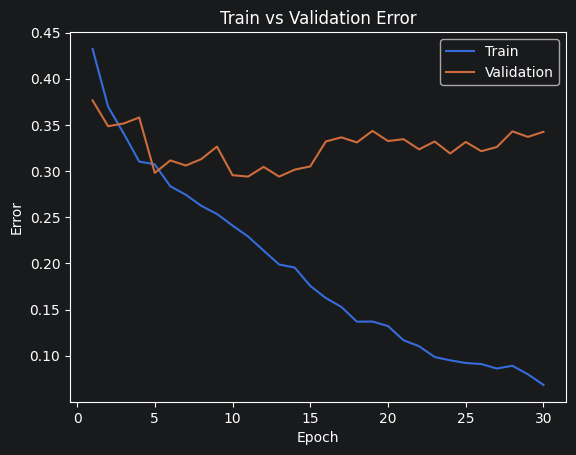

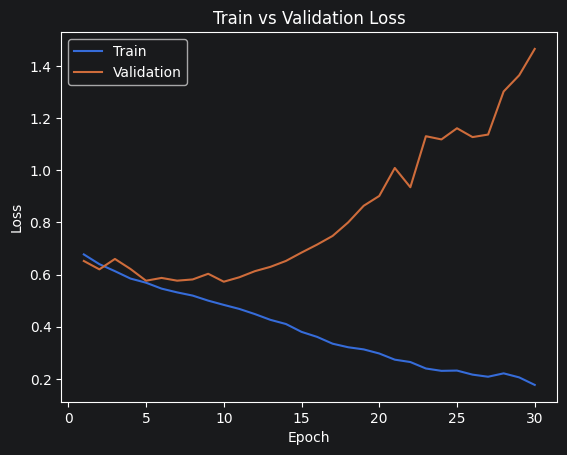

In [19]:
large_net = LargeNet()
train_net(large_net, batch_size=16, learning_rate=0.01, num_epochs=30)
model_path = get_model_name(large_net.name, batch_size=16, learning_rate=0.01, epoch=29)
plot_training_curve(model_path)
"""each epoch takes longer because the batch size is small,faster,causing faster convergence but a noisier training curve, and leads to overfitting  """

## Part 4. Hyperparameter Search [6 pt]

### Part (a) - 2pt

Based on the plots from above, choose another set of values for the hyperparameters (network, batch_size, learning_rate)
that you think would help you improve the validation accuracy. Justify your choice.

In [ ]:
"""large_net = LargeNet()
train_net(large_net, batch_size=1024, learning_rate=0.002, num_epochs=30)
model_path = get_model_name(large_net.name, batch_size=1024, learning_rate=0.002, epoch=29)
plot_training_curve(model_path)"""

### Part (b) - 1pt

Train the model with the hyperparameters you chose in part(a), and include the training curve.

Epoch 1: Train err: 0.488875, Train loss: 0.6930695548653603 |Validation err: 0.4965, Validation loss: 0.6931596398353577
Epoch 2: Train err: 0.485875, Train loss: 0.6930088624358177 |Validation err: 0.4965, Validation loss: 0.6930715143680573
Epoch 3: Train err: 0.48225, Train loss: 0.6929574385285378 |Validation err: 0.491, Validation loss: 0.692997932434082
Epoch 4: Train err: 0.479625, Train loss: 0.6929030939936638 |Validation err: 0.491, Validation loss: 0.692909836769104
Epoch 5: Train err: 0.475125, Train loss: 0.6928273364901543 |Validation err: 0.487, Validation loss: 0.6928119957447052
Epoch 6: Train err: 0.471375, Train loss: 0.6927386745810509 |Validation err: 0.4825, Validation loss: 0.6927183568477631
Epoch 7: Train err: 0.466875, Train loss: 0.6926626563072205 |Validation err: 0.4715, Validation loss: 0.6926120221614838
Epoch 8: Train err: 0.465625, Train loss: 0.6925940811634064 |Validation err: 0.467, Validation loss: 0.6925098896026611
Epoch 9: Train err: 0.463, Trai

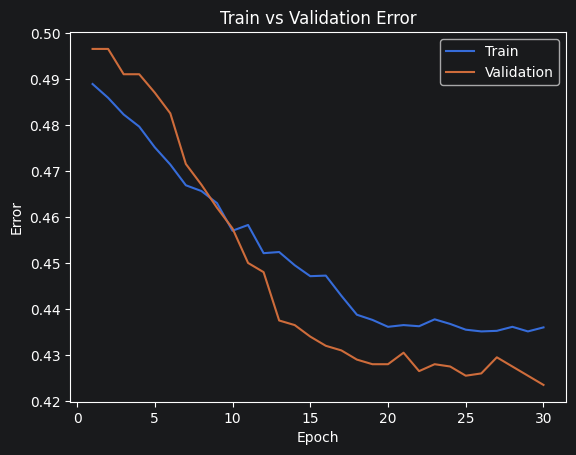

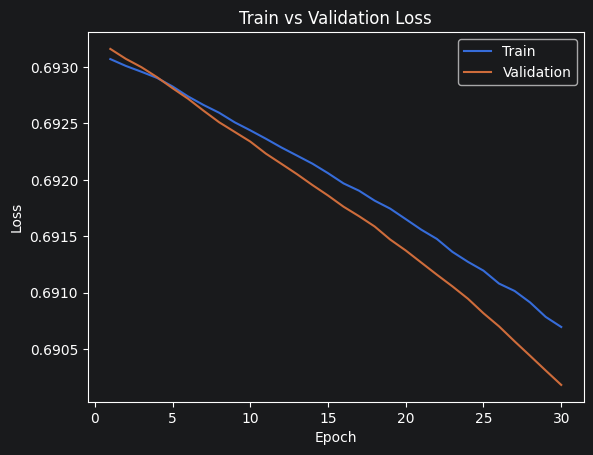

In [20]:
large_net = LargeNet()
train_net(large_net, batch_size=1024, learning_rate=0.002, num_epochs=30)
model_path = get_model_name(large_net.name, batch_size=1024, learning_rate=0.002, epoch=29)
plot_training_curve(model_path)

### Part (c) - 2pt

Based on your result from Part(a), suggest another set of hyperparameter values to try. 
Justify your choice.

In [ ]:
large_net = LargeNet()
train_net(large_net, batch_size=64, learning_rate=0.01, num_epochs=30)
model_path = get_model_name(large_net.name, batch_size=64, learning_rate=0.01, epoch=29)
plot_training_curve(model_path)
"""i realized my batch size is to big, so the updates per epoch will be very small, the lr rate 0.002 is also failing because the steps will be very small for the model ton learn, ill try batchsize 64 and leaning rate 0.01 improving the updates per epoch and better weigh updates within our 30 epoch"""

### Part (d) - 1pt

Train the model with the hyperparameters you chose in part(c), and include the training curve.

Epoch 1: Train err: 0.470625, Train loss: 0.6924575219154357 |Validation err: 0.4275, Validation loss: 0.6888912562280893
Epoch 2: Train err: 0.442125, Train loss: 0.6861939315795899 |Validation err: 0.425, Validation loss: 0.6786068454384804
Epoch 3: Train err: 0.408125, Train loss: 0.672941005706787 |Validation err: 0.3895, Validation loss: 0.6593405585736036
Epoch 4: Train err: 0.37875, Train loss: 0.6539539246559143 |Validation err: 0.417, Validation loss: 0.6609608121216297
Epoch 5: Train err: 0.356875, Train loss: 0.6371989593505859 |Validation err: 0.35, Validation loss: 0.6300069019198418
Epoch 6: Train err: 0.33975, Train loss: 0.6169495365619659 |Validation err: 0.3395, Validation loss: 0.6191455014050007
Epoch 7: Train err: 0.3335, Train loss: 0.6050948171615601 |Validation err: 0.3315, Validation loss: 0.6071332488209009
Epoch 8: Train err: 0.31425, Train loss: 0.5860047106742858 |Validation err: 0.3275, Validation loss: 0.5986186508089304
Epoch 9: Train err: 0.29775, Train

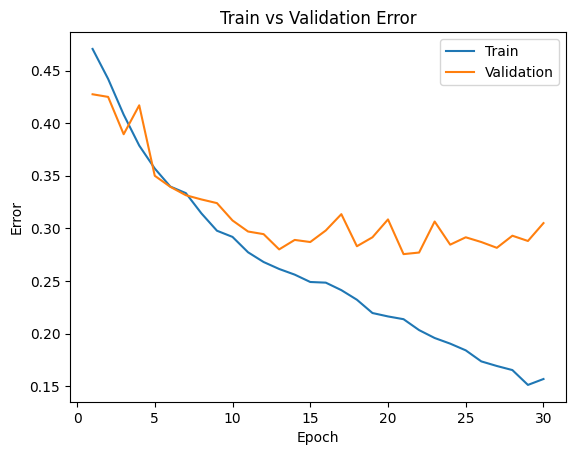

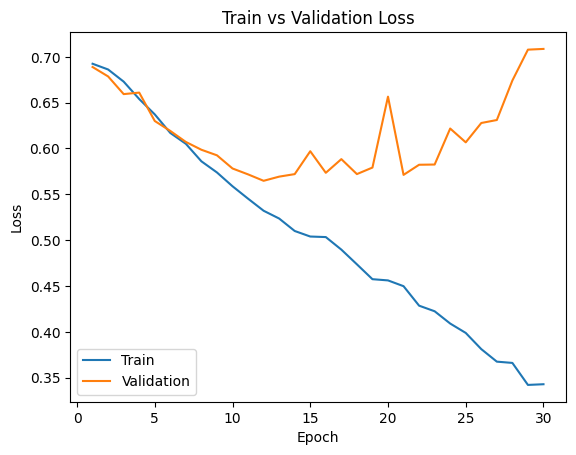

In [16]:
large_net = LargeNet()
train_net(large_net, batch_size=64, learning_rate=0.01, num_epochs=30)
model_path = get_model_name(large_net.name, batch_size=64, learning_rate=0.01, epoch=29)
plot_training_curve(model_path)

## Part 4. Evaluating the Best Model [15 pt]


### Part (a) - 1pt

Choose the **best** model that you have so far. This means choosing the best model checkpoint,
including the choice of `small_net` vs `large_net`, the `batch_size`, `learning_rate`, 
**and the epoch number**.

Modify the code below to load your chosen set of weights to the model object `net`.

In [19]:
net = LargeNet()
model_path = get_model_name(net.name, batch_size=64, learning_rate=0.01, epoch=13)
state = torch.load(model_path)
net.load_state_dict(state)

<All keys matched successfully>

### Part (b) - 2pt

Justify your choice of model from part (a).

In [ ]:
"""Large net has a better performance in underfitting with a training error rate at 28, """

### Part (c) - 2pt

Using the code in Part 0, any code from lecture notes, or any code that you write,
compute and report the **test classification error** for your chosen model.

In [20]:
# If you use the `evaluate` function provided in part 0, you will need to 
# set batch_size > 1
train_loader, val_loader, test_loader, classes = get_data_loader(
    target_classes=["cat", "dog"], 
    batch_size=64)

### Part (d) - 3pt

How does the test classification error compare with the **validation error**?
Explain why you would expect the test error to be *higher* than the validation error.

### Part (e) - 2pt

Why did we only use the test data set at the very end?
Why is it important that we use the test data as little as possible?

### Part (f) - 5pt

How does the your best CNN model compare with an 2-layer ANN model (no convolutional layers) on classifying cat and dog images. You can use a 2-layer ANN architecture similar to what you used in Lab 1. You should explore different hyperparameter settings to determine how well you can do on the validation dataset. Once satisified with the performance, you may test it out on the test data.

Hint: The ANN in lab 1 was applied on greyscale images. The cat and dog images are colour (RGB) and so you will need to flatted and concatinate all three colour layers before feeding them into an ANN.